# Scalable Diffusion Models with Transformer (DiT)

This notebook samples from pre-trained DiT models. DiTs are class-conditional latent diffusion models trained on ImageNet that use transformers in place of U-Nets as the DDPM backbone. DiT outperforms all prior diffusion models on the ImageNet benchmarks.

[Project Page](https://www.wpeebles.com/DiT) | [HuggingFace Space](https://huggingface.co/spaces/wpeebles/DiT) | [Paper](http://arxiv.org/abs/2212.09748) | [GitHub](github.com/facebookresearch/DiT)

# 1. Setup

We recommend using GPUs (Runtime > Change runtime type > Hardware accelerator > GPU). Run this cell to clone the DiT GitHub repo and setup PyTorch. You only have to run this once.

In [1]:
%cd ../

/home/sepuhopar/dev


In [2]:
#!git clone https://github.com/facebookresearch/DiT.git
import DiT, os
os.chdir('DiT')
#os.environ['PYTHONPATH'] = '/env/python:/content/DiT'
#!pip install diffusers timm --upgrade
# DiT imports:
import torch
from torchvision.utils import save_image
from diffusion import create_diffusion
from diffusers.models import AutoencoderKL
from download import find_model
from models import DiT_XL_2
from PIL import Image
from IPython.display import display
torch.set_grad_enabled(False)
device = "cuda" if torch.cuda.is_available() else "cpu"
if device == "cpu":
    print("GPU not found. Using CPU instead.")

Multiple distributions found for package optimum. Picked distribution: optimum
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


# Download DiT-XL/2 Models

You can choose between a 512x512 model and a 256x256 model. You can swap-out the LDM VAE, too.

In [3]:
image_size = 256 #@param [256, 512]
vae_model = "stabilityai/sd-vae-ft-ema" #@param ["stabilityai/sd-vae-ft-mse", "stabilityai/sd-vae-ft-ema"]
latent_size = int(image_size) // 8
# Load model:
model = DiT_XL_2(input_size=latent_size).to(device)
state_dict = find_model(f"DiT-XL-2-{image_size}x{image_size}.pt")
model.load_state_dict(state_dict)
model.eval() # important!
vae = AutoencoderKL.from_pretrained(vae_model).to(device)

/home/sepuhopar/miniconda3/envs/ldm/lib/python3.11/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


# 2. Sample from Pre-trained DiT Models

You can customize several sampling options. For the full list of ImageNet classes, [check out this](https://gist.github.com/yrevar/942d3a0ac09ec9e5eb3a).

In [ ]:
# Set user inputs:
seed = 0 #@param {type:"number"}
torch.manual_seed(seed)
num_sampling_steps = 250 #@param {type:"slider", min:0, max:1000, step:1}
cfg_scale = 4 #@param {type:"slider", min:1, max:10, step:0.1}
class_labels = 207, 360, 387, 974, 88, 979, 417, 279 #@param {type:"raw"}
samples_per_row = 4 #@param {type:"number"}

# Create diffusion object:
diffusion = create_diffusion(str(num_sampling_steps))

# Create sampling noise:
n = len(class_labels)
z = torch.randn(n, 4, latent_size, latent_size, device=device)
y = torch.tensor(class_labels, device=device)

# Setup classifier-free guidance:
z = torch.cat([z, z], 0)
y_null = torch.tensor([1000] * n, device=device)
y = torch.cat([y, y_null], 0)
model_kwargs = dict(y=y, cfg_scale=cfg_scale)

# Sample images:
samples = diffusion.p_sample_loop(
    model.forward_with_cfg, z.shape, z, clip_denoised=False, 
    model_kwargs=model_kwargs, progress=True, device=device
)
samples, _ = samples.chunk(2, dim=0)  # Remove null class samples
samples = vae.decode(samples / 0.18215).sample

# Save and display images:
save_image(samples, "sample.png", nrow=int(samples_per_row), 
           normalize=True, value_range=(-1, 1))
samples = Image.open("sample.png")
display(samples)

# 3. Ensemble Variance $U_{\text{ens}}(t, c)$

**Ensemble variance** measures how much the model’s clean-image prediction $\hat{x}_0$ disagrees across different random noise seeds at the same timestep $t$ and class $c$:

$$U_{\text{ens}}(t, c) = \mathrm{Var}_k\big[D_0(x_t^{(k)}, t, c)\big]$$

For each class $c$, we draw $K$ initial latents $z^{(1)}, \ldots, z^{(K)} \sim \mathcal{N}(0, I)$, run the **full** reverse diffusion path for each seed, record $\hat{x}_0 = D_0(x_t, t, c)$ at every spaced timestep, then compute **per-patch** variance across the $K$ runs (variance within each DiT patch, averaged over channels and patch pixels).

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# Ensemble variance settings
K = 16  #@param {type:"integer"}
ens_cfg_scale = 4.0  #@param {type:"slider", min:1, max:10, step:0.1}
ens_num_sampling_steps = 250  #@param {type:"slider", min:10, max:1000, step:1}
ens_class_labels = (207,)  #@param {type:"raw"}  # one or more ImageNet class ids
ens_seed_base = 0  #@param {type:"integer"}
patch_size = 2  # DiT-XL/2 latent patch size

ens_diffusion = create_diffusion(str(ens_num_sampling_steps))
shape = (1, 4, latent_size, latent_size)


def x0_to_patch_variance(x0_ensemble, patch_size=2):
    """Per-patch variance of K x0 predictions: (K,C,H,W) -> (H//p, W//p)."""
    var_map = x0_ensemble.var(dim=0)  # (C, H, W)
    c, h, w = var_map.shape
    var_map = var_map.reshape(
        c, h // patch_size, patch_size, w // patch_size, patch_size
    )
    return var_map.mean(dim=(0, 2, 4))


def run_ensemble_x0_for_class(class_label, K=16, seed_base=0, progress=True):
    """Run K full-path samples for one class; return x0 preds and original timestep bins."""
    x0_by_t = []
    timestep_bins = [
        ens_diffusion.timestep_map[i]
        for i in range(ens_diffusion.num_timesteps - 1, -1, -1)
    ]

    iterator = range(K)
    if progress:
        iterator = tqdm(iterator, desc=f"class {class_label}", leave=False)

    for k in iterator:
        torch.manual_seed(seed_base + k)
        z = torch.randn(*shape, device=device)
        z_cfg = torch.cat([z, z], dim=0)
        y = torch.tensor([class_label, 1000], device=device)
        model_kwargs = dict(y=y, cfg_scale=ens_cfg_scale)

        traj = []
        for out in ens_diffusion.p_sample_loop_progressive(
            model.forward_with_cfg,
            z_cfg.shape,
            z_cfg,
            clip_denoised=False,
            model_kwargs=model_kwargs,
            device=device,
            progress=False,
        ):
            traj.append(out["pred_xstart"][:1].cpu())
        print(traj[0].shape)
        x0_by_t.append(torch.stack(traj, dim=0))  # (T, 1, C, H, W)

    # (K, T, C, H, W)
    x0_ensemble = torch.stack([x.squeeze(1) for x in x0_by_t], dim=0)
    return x0_ensemble, timestep_bins


# U_ens[c][t]: per-patch variance map; also store scalar mean per (c, t)
U_ens_patch = {}
U_ens_mean = {}

for class_label in ens_class_labels:
    x0_ensemble, timestep_bins = run_ensemble_x0_for_class(
        class_label, K=K, seed_base=ens_seed_base, progress=True
    )
    num_t = x0_ensemble.shape[1]
    patch_maps = torch.stack(
        [x0_to_patch_variance(x0_ensemble[:, t], patch_size) for t in range(num_t)],
        dim=0,
    )  # (T, ph, pw)
    U_ens_patch[class_label] = patch_maps.numpy()
    U_ens_mean[class_label] = {
        int(timestep_bins[t]): float(patch_maps[t].mean()) for t in range(num_t)
    }
    print(
        f"class {class_label}: {num_t} timestep bins, "
        f"patch grid {patch_maps.shape[-2]}x{patch_maps.shape[-1]}, "
        f"mean U_ens range [{patch_maps.mean(dim=(1, 2)).min():.4f}, "
        f"{patch_maps.mean(dim=(1, 2)).max():.4f}]"
    )



class 207:   0%|          | 0/16 [00:00<?, ?it/s]

torch.Size([1, 4, 32, 32])
torch.Size([1, 4, 32, 32])
torch.Size([1, 4, 32, 32])
torch.Size([1, 4, 32, 32])
torch.Size([1, 4, 32, 32])
torch.Size([1, 4, 32, 32])
torch.Size([1, 4, 32, 32])
torch.Size([1, 4, 32, 32])
torch.Size([1, 4, 32, 32])
torch.Size([1, 4, 32, 32])
torch.Size([1, 4, 32, 32])
torch.Size([1, 4, 32, 32])
torch.Size([1, 4, 32, 32])
torch.Size([1, 4, 32, 32])
torch.Size([1, 4, 32, 32])
torch.Size([1, 4, 32, 32])
class 207: 250 timestep bins, patch grid 16x16, mean U_ens range [0.0247, 0.7211]


250


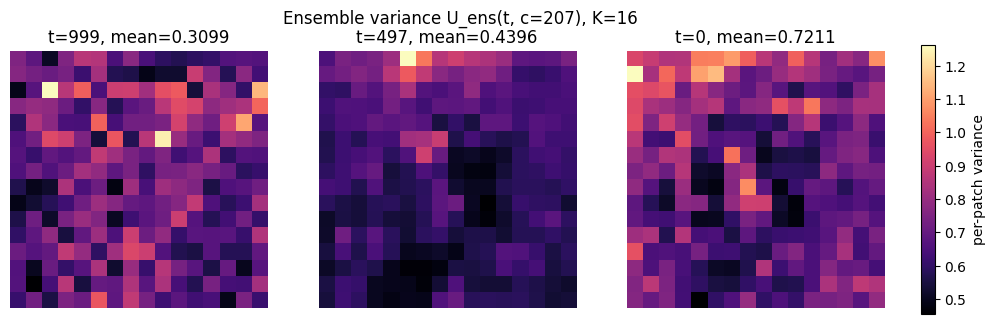

In [16]:
# Visualize per-patch U_ens at early / mid / late timesteps for the first class
vis_class = ens_class_labels[0]
maps = U_ens_patch[vis_class]
t_show = [0, len(maps) // 2, len(maps) - 1]
t_labels = list(U_ens_mean[vis_class].keys())
print(len(t_labels))
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, ti in zip(axes, t_show):
    im = ax.imshow(maps[ti], cmap="magma")
    ax.set_title(f"t={t_labels[ti]}, mean={maps[ti].mean():.4f}")
    ax.axis("off")
fig.colorbar(im, ax=axes, fraction=0.02, pad=0.04, label="per-patch variance")
fig.suptitle(f"Ensemble variance U_ens(t, c={vis_class}), K={K}")
#plt.tight_layout()
plt.show()